# Simplified EMG Hand Gesture Classification Pipeline

This is a beginner-friendly version of the EMG notebook. It avoids advanced concepts such as random seeds, sampling rate, and sliding windows.

The goal is simple:

1. Load the EMG dataset  
2. Explore the data  
3. Create simple features from the 8 EMG channels  
4. Train a classifier  
5. Evaluate the results

In this simplified version, each row in the feature table represents one **subject + gesture class** combination.

## 1. Import Libraries

We only import the libraries needed for data handling, plotting, feature extraction, model training, and evaluation.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.decomposition import PCA

## 2. Load the Dataset

The dataset contains time, 8 EMG channels, the gesture class, and the subject label.

In [2]:
DATA_PATH = 'EMG-data.csv'

channel_cols = [f'channel{i}' for i in range(1, 9)]

gesture_names = {
    0: 'Unmarked',
    1: 'Rest',
    2: 'Fist',
    3: 'Wrist Flexion',
    4: 'Wrist Extension',
    5: 'Radial Deviation',
    6: 'Ulnar Deviation',
    7: 'Extended Palm'
}

df = pd.read_csv(DATA_PATH)

print(df.shape)
df.head()

(4237907, 11)


,time,channel1,channel2,channel3,channel4,channel5,channel6,channel7,channel8,class,label
0,1,0.00001,-0.00002,-0.00001,-0.00003,0.00000,-0.00001,0.00000,-0.00001,0,1
1,5,0.00001,-0.00002,-0.00001,-0.00003,0.00000,-0.00001,0.00000,-0.00001,0,1
2,6,-0.00001,0.00001,0.00002,0.00000,0.00001,-0.00002,-0.00001,0.00001,0,1
3,7,-0.00001,0.00001,0.00002,0.00000,0.00001,-0.00002,-0.00001,0.00001,0,1
4,8,-0.00001,0.00001,0.00002,0.00000,0.00001,-0.00002,-0.00001,0.00001,0,1


## 3. Basic Data Exploration

Before training a model, we first inspect the dataset structure, check missing values, and see how many samples exist for each gesture and subject.

In [3]:
print('Dataset shape:', df.shape)
print('Column types:')
print(df.dtypes)

print('Missing values:')
print(df.isnull().sum())

print('Gesture classes:')
print(df['class'].value_counts().sort_index())

print('Number of subjects:', df['label'].nunique())

Dataset shape: (4237907, 11)
Column types:
time          int64
channel1    float64
channel2    float64
channel3    float64
channel4    float64
channel5    float64
channel6    float64
channel7    float64
channel8    float64
class         int64
label         int64
dtype: object
Missing values:
time        0
channel1    0
channel2    0
channel3    0
channel4    0
channel5    0
channel6    0
channel7    0
channel8    0
class       0
label       0
dtype: int64
Gesture classes:
class
0    2725157
1     250055
2     243193
3     249494
4     251570
5     251733
6     253009
7      13696
Name: count, dtype: int64
Number of subjects: 36


In [4]:
print('Number of subjects:', df['label'].nunique())

Number of subjects: 36


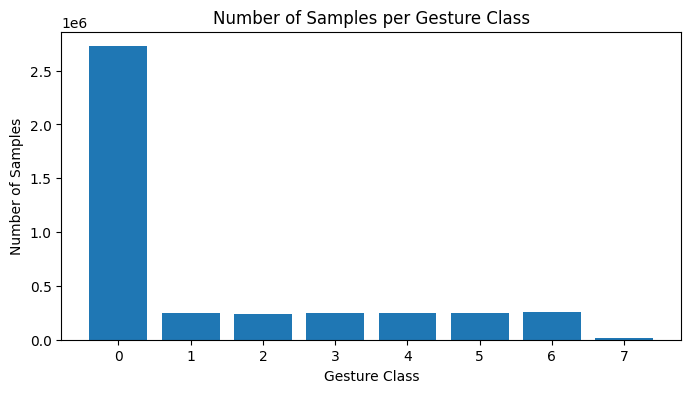

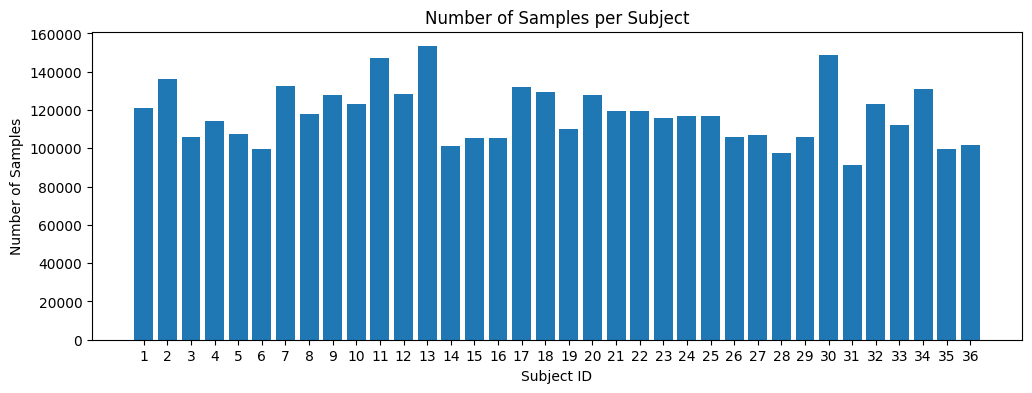

In [5]:
plt.figure(figsize=(8, 4))
class_counts = df['class'].value_counts().sort_index()
plt.bar(class_counts.index.astype(str), class_counts.values)
plt.title('Number of Samples per Gesture Class')
plt.xlabel('Gesture Class')
plt.ylabel('Number of Samples')
plt.show()

plt.figure(figsize=(12, 4))
subject_counts = df['label'].value_counts().sort_index()
plt.bar(subject_counts.index.astype(str), subject_counts.values)
plt.title('Number of Samples per Subject')
plt.xlabel('Subject ID')
plt.ylabel('Number of Samples')
plt.show()

In [6]:
print("Range of samples per subject:", df['label'].value_counts().min(), "-", df['label'].value_counts().max())

Range of samples per subject: 91023 - 153240


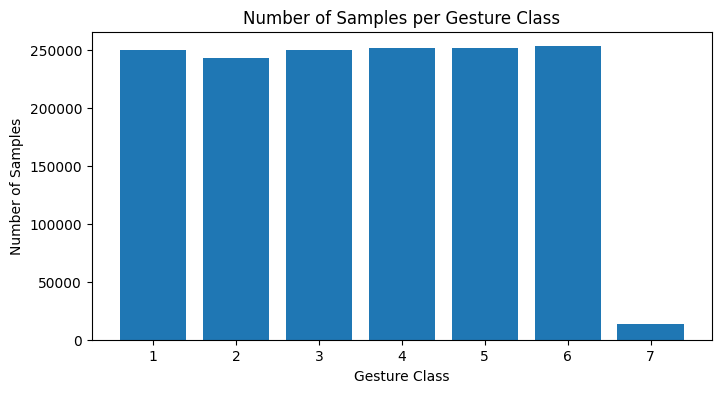

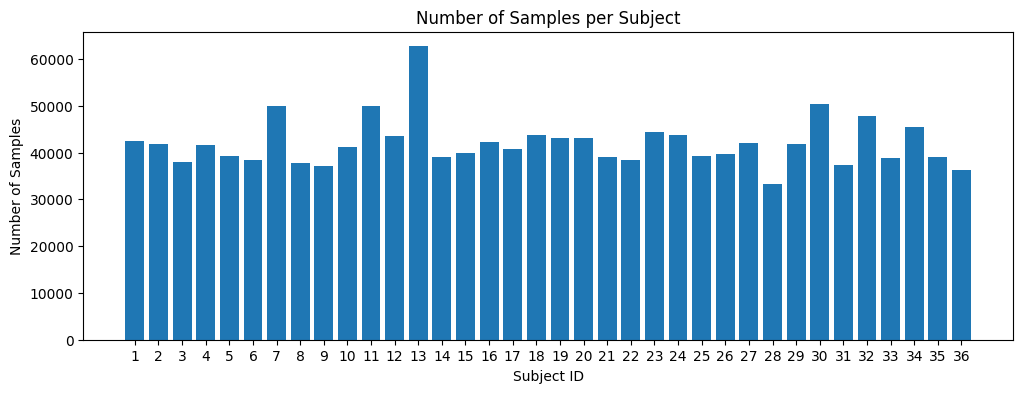

In [7]:
df_without_unmarked = df[df['class'] != 0]

plt.figure(figsize=(8, 4))
class_counts = df_without_unmarked['class'].value_counts().sort_index()
plt.bar(class_counts.index.astype(str), class_counts.values)
plt.title('Number of Samples per Gesture Class')
plt.xlabel('Gesture Class')
plt.ylabel('Number of Samples')
plt.show()

plt.figure(figsize=(12, 4))
subject_counts = df_without_unmarked['label'].value_counts().sort_index()
plt.bar(subject_counts.index.astype(str), subject_counts.values)
plt.title('Number of Samples per Subject')
plt.xlabel('Subject ID')
plt.ylabel('Number of Samples')
plt.show()

In [8]:
print('Range of samples per subject (after removing unmarked):', df_without_unmarked['label'].value_counts().min(), '-', df_without_unmarked['label'].value_counts().max())

Range of samples per subject (after removing unmarked): 33244 - 62706


## 4. Visualize Raw EMG Signals

This plot shows how the 8 EMG channels behave for one subject performing one gesture. Each channel represents a sensor placed around the forearm.

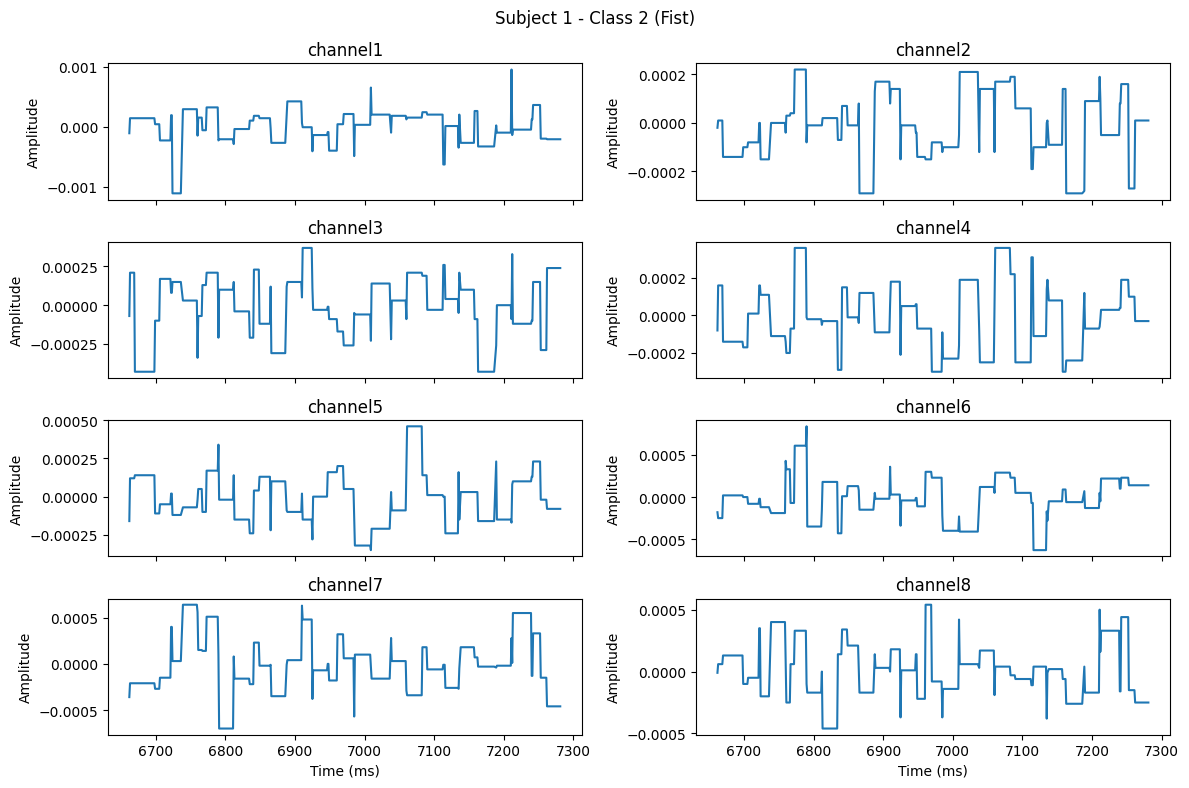

In [9]:
subject_id = df['label'].iloc[0] # Just take the first subject for visualization
gesture_class = 2   # Fist

subject1_class2 = df[(df['label'] == subject_id) & (df['class'] == gesture_class)].iloc[:600] # Take the first 600 samples of this gesture for this subject
# Why 600? Because the dataset is sampled at 200Hz, so 600 samples correspond to 3 seconds of data, which is a reasonable window to visualize the gesture.

fig, axes = plt.subplots(4, 2, figsize=(12, 8), sharex=True)

for i, ch in enumerate(channel_cols):
    ax = axes.flat[i]
    ax.plot(subject1_class2['time'], subject1_class2[ch])
    ax.set_title(ch)
    ax.set_ylabel('Amplitude')

axes[-1, 0].set_xlabel('Time (ms)')
axes[-1, 1].set_xlabel('Time (ms)')
plt.suptitle(f'Subject {subject_id} - Class {gesture_class} ({gesture_names[gesture_class]})')
plt.tight_layout()
plt.show()

In [10]:
mean_abs_amplitudes = {}

for ch in channel_cols:
    mean_abs_amplitudes[ch] = np.mean(np.abs(subject1_class2[ch]))

print("Mean Absolute Amplitude per Channel:\n")

for ch, value in mean_abs_amplitudes.items():
    print(f"{ch}: {value:.6f}")

max_ch = max(mean_abs_amplitudes, key=mean_abs_amplitudes.get)
min_ch = min(mean_abs_amplitudes, key=mean_abs_amplitudes.get)

print(f"\nMost active channel: {max_ch}")
print(f"Least active channel: {min_ch}")

Mean Absolute Amplitude per Channel:

channel1: 0.000208
channel2: 0.000113
channel3: 0.000158
channel4: 0.000141
channel5: 0.000131
channel6: 0.000189
channel7: 0.000231
channel8: 0.000175

Most active channel: channel7
Least active channel: channel2


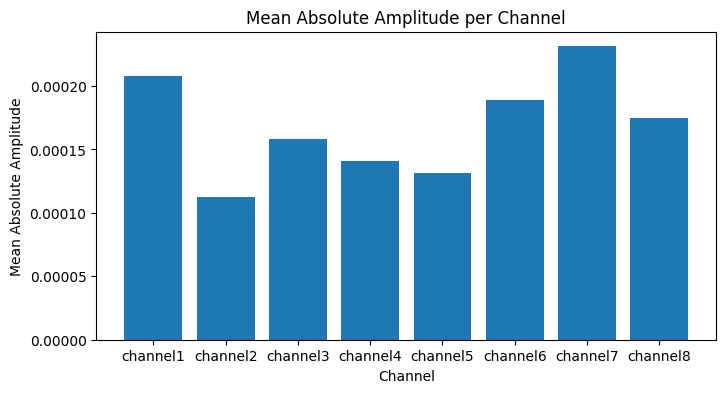

In [11]:
plt.figure(figsize=(8,4))

plt.bar(mean_abs_amplitudes.keys(),
        mean_abs_amplitudes.values())

plt.title('Mean Absolute Amplitude per Channel')
plt.xlabel('Channel')
plt.ylabel('Mean Absolute Amplitude')
plt.show()

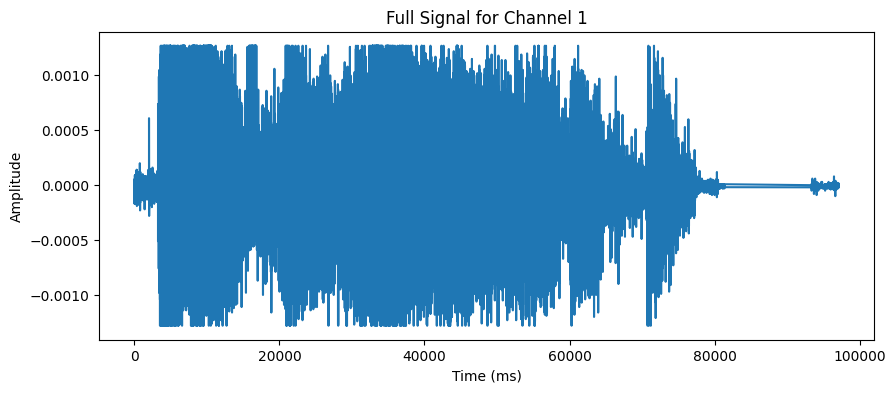

In [12]:
# plot of the full signal for channel 1
plt.figure(figsize=(10, 4))
plt.plot(df['time'], df['channel1'])
plt.title('Full Signal for Channel 1')
plt.xlabel('Time (ms)')
plt.ylabel('Amplitude')
plt.show()

In [13]:
unique_subjects = df['label'].unique()

subject_id_1 = unique_subjects[0]
subject_id_2 = unique_subjects[1]

print(subject_id_1)
print(subject_id_2)

1
2


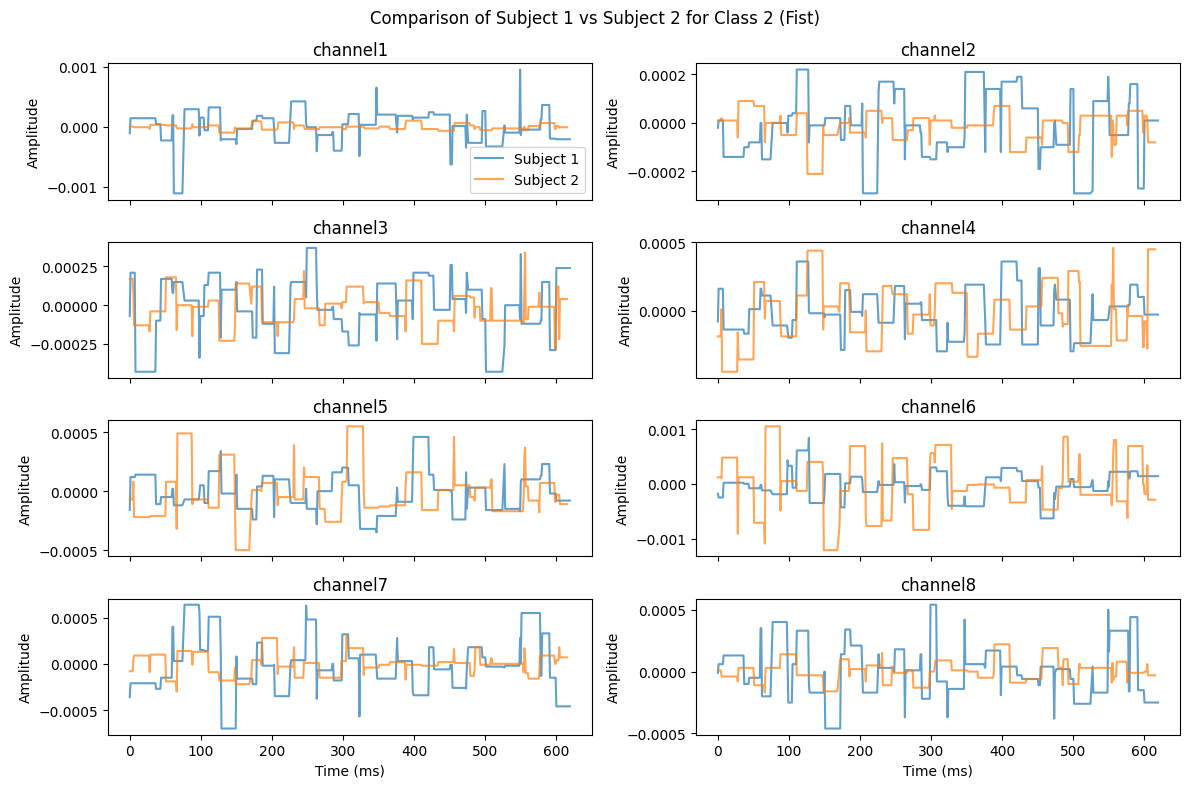

In [14]:
# Compare Subject 1 vs Subject 2 for the same gesture (Fist)
unique_subjects = df['label'].unique()

subject_id_1 = unique_subjects[0]
subject_id_2 = unique_subjects[1]
gesture_class = 2  # Fist
subject1_class2 = df[(df['label'] == subject_id_1) & (df['class'] == gesture_class)].iloc[:600]
subject2_class2 = df[(df['label'] == subject_id_2) & (df['class'] == gesture_class)].iloc[:600]

segment_1_time = subject1_class2['time'] - subject1_class2['time'].iloc[0]
segment_2_time = subject2_class2['time'] - subject2_class2['time'].iloc[0]

fig, axes = plt.subplots(4, 2, figsize=(12, 8), sharex=True)
for i, ch in enumerate(channel_cols):
    ax = axes.flat[i]
    ax.plot(segment_1_time, subject1_class2[ch], label=f'Subject {subject_id_1}', alpha=0.7)
    ax.plot(segment_2_time, subject2_class2[ch], label=f'Subject {subject_id_2}', alpha=0.7)
    ax.set_title(ch)
    ax.set_ylabel('Amplitude')
    if i == 0:
        ax.legend()
        axes[-1, 0].set_xlabel('Time (ms)')
        axes[-1, 1].set_xlabel('Time (ms)')
plt.suptitle(f'Comparison of Subject {subject_id_1} vs Subject {subject_id_2} for Class {gesture_class} ({gesture_names[gesture_class]})')
plt.tight_layout()
plt.show()

Subject 2 Mean Absolute Amplitude per Channel:

channel1: 0.000038
channel2: 0.000048
channel3: 0.000088
channel4: 0.000189
channel5: 0.000163
channel6: 0.000410
channel7: 0.000088
channel8: 0.000068


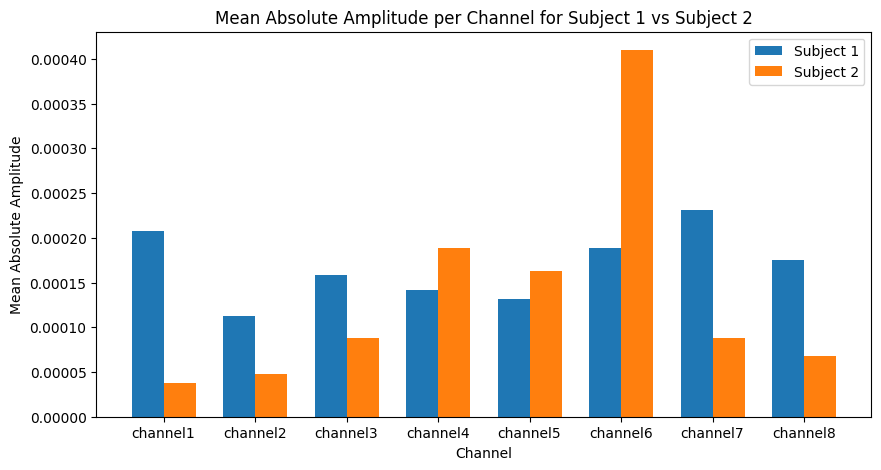

In [15]:
# Subject 2 average amplitude across channels
mean_abs_amplitudes_2 = {}
for ch in channel_cols:
    mean_abs_amplitudes_2[ch] = np.mean(np.abs(subject2_class2[ch]))
print("Subject 2 Mean Absolute Amplitude per Channel:\n")
for ch, value in mean_abs_amplitudes_2.items():
    print(f"{ch}: {value:.6f}")
 # bar plot comparing subject 1 and subject 2 mean absolute amplitudes
channels = list(mean_abs_amplitudes.keys())
x = np.arange(len(channels))
width = 0.35
plt.figure(figsize=(10, 5))
plt.bar(x - width/2, mean_abs_amplitudes.values(), width, label=f'Subject {subject_id_1}')
plt.bar(x + width/2, mean_abs_amplitudes_2.values(), width, label=f'Subject {subject_id_2}')
plt.xticks(x, channels)
plt.xlabel('Channel')
plt.ylabel('Mean Absolute Amplitude')
plt.title('Mean Absolute Amplitude per Channel for Subject 1 vs Subject 2')
plt.legend()
plt.show()

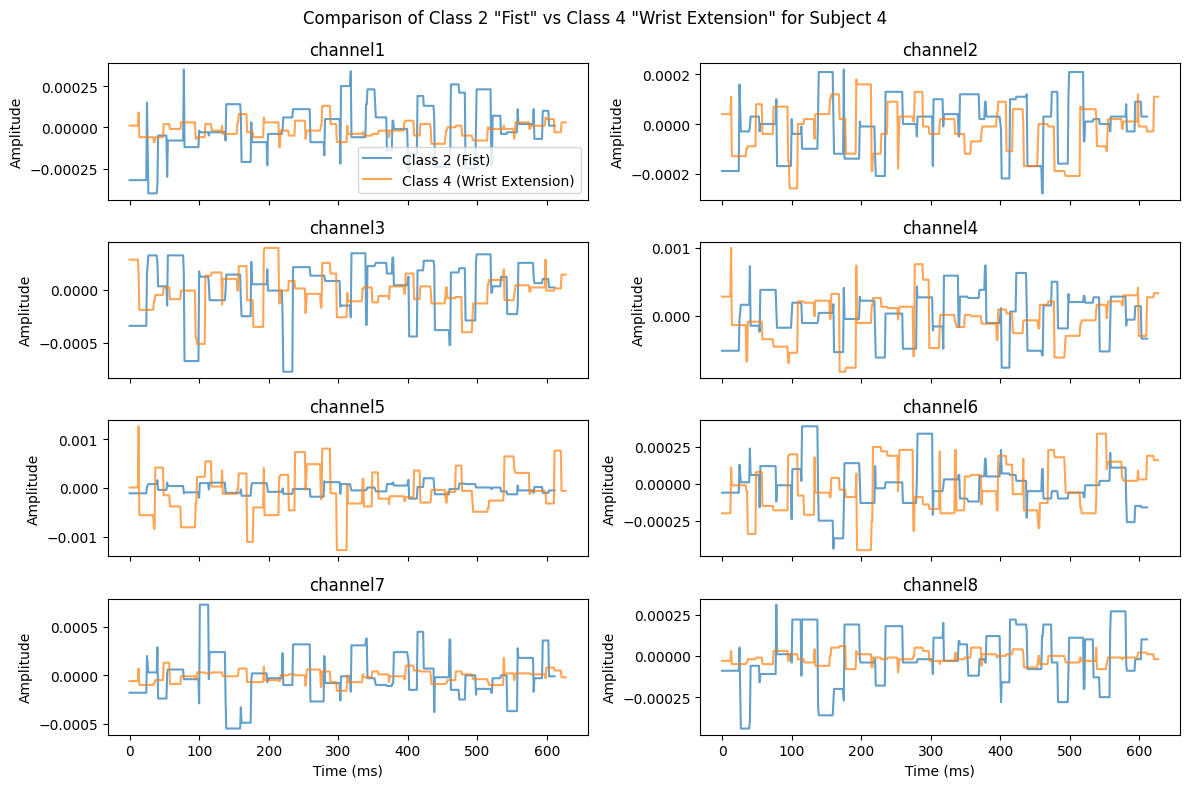

In [16]:
# Compare Subject 4 with two different gestures (Fist vs Wrist Extension)
subject_id = unique_subjects[3]  # Subject 4
gesture_class_1 = 2  # Fist
gesture_class_2 = 4  # Wrist Extension
subject4_class2 = df[(df['label'] == subject_id) & (df['class'] == gesture_class_1)].iloc[:600]
subject4_class4 = df[(df['label'] == subject_id) & (df['class'] == gesture_class_2)].iloc[:600]
segment_1_time = subject4_class2['time'] - subject4_class2['time'].iloc[0]
segment_2_time = subject4_class4['time'] - subject4_class4['time'].iloc[0]
fig, axes = plt.subplots(4, 2, figsize=(12, 8), sharex=True)
for i, ch in enumerate(channel_cols):
    ax = axes.flat[i]
    ax.plot(segment_1_time, subject4_class2[ch], label=f'Class {gesture_class_1} ({gesture_names[gesture_class_1]})', alpha=0.7)
    ax.plot(segment_2_time, subject4_class4[ch], label=f'Class {gesture_class_2} ({gesture_names[gesture_class_2]})', alpha=0.7)
    ax.set_title(ch)
    ax.set_ylabel('Amplitude')
    if i == 0:
        ax.legend()
axes[-1, 0].set_xlabel('Time (ms)')
axes[-1, 1].set_xlabel('Time (ms)')
plt.suptitle(f'Comparison of Class {gesture_class_1} \"Fist\" vs Class {gesture_class_2} \"Wrist Extension\" for Subject {subject_id}')
plt.tight_layout()
plt.show()

Subject 4 Mean Absolute Amplitude per Channel for Fist:

channel1: 0.000125
channel2: 0.000093
channel3: 0.000223
channel4: 0.000289
channel5: 0.000083
channel6: 0.000112
channel7: 0.000180
channel8: 0.000142

Subject 4 Mean Absolute Amplitude per Channel for Wrist Extension:

channel1: 0.000039
channel2: 0.000076
channel3: 0.000126
channel4: 0.000252
channel5: 0.000373
channel6: 0.000153
channel7: 0.000048
channel8: 0.000031


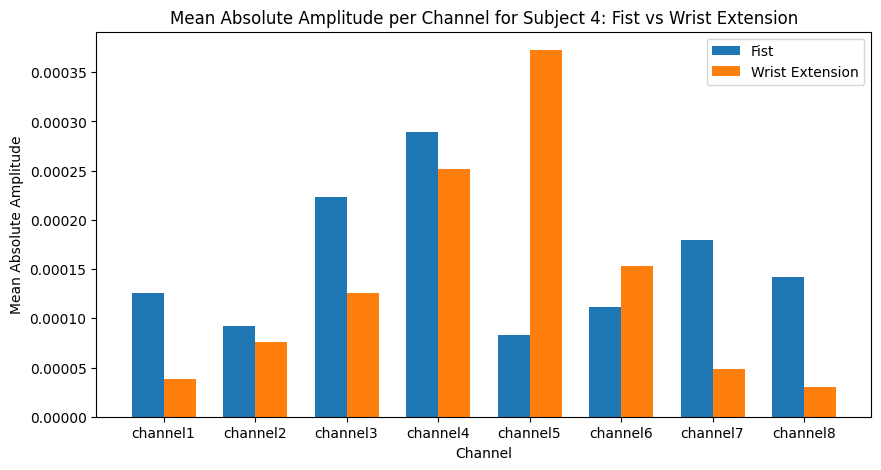

In [17]:
# Subject 4 average amplitude across channels for Fist vs Wrist Extension
mean_abs_amplitudes_fist = {}
mean_abs_amplitudes_wrist_extension = {}
for ch in channel_cols:
    mean_abs_amplitudes_fist[ch] = np.mean(np.abs(subject4_class2[ch]))
    mean_abs_amplitudes_wrist_extension[ch] = np.mean(np.abs(subject4_class4[ch]))
print("Subject 4 Mean Absolute Amplitude per Channel for Fist:\n")
for ch, value in mean_abs_amplitudes_fist.items():
    print(f"{ch}: {value:.6f}")
print("\nSubject 4 Mean Absolute Amplitude per Channel for Wrist Extension:\n")
for ch, value in mean_abs_amplitudes_wrist_extension.items():
    print(f"{ch}: {value:.6f}")
# bar plot comparing subject 4 mean absolute amplitudes for Fist vs Wrist Extension
channels = list(mean_abs_amplitudes_fist.keys())
x = np.arange(len(channels))
width = 0.35
plt.figure(figsize=(10, 5))
plt.bar(x - width/2, mean_abs_amplitudes_fist.values(), width, label='Fist')
plt.bar(x + width/2, mean_abs_amplitudes_wrist_extension.values(), width, label='Wrist Extension')
plt.xticks(x, channels)
plt.xlabel('Channel')
plt.ylabel('Mean Absolute Amplitude')
plt.title('Mean Absolute Amplitude per Channel for Subject 4: Fist vs Wrist Extension')
plt.legend()
plt.show()

In [18]:
df.columns

Index(['time', 'channel1', 'channel2', 'channel3', 'channel4', 'channel5',
       'channel6', 'channel7', 'channel8', 'class', 'label'],
      dtype='str')

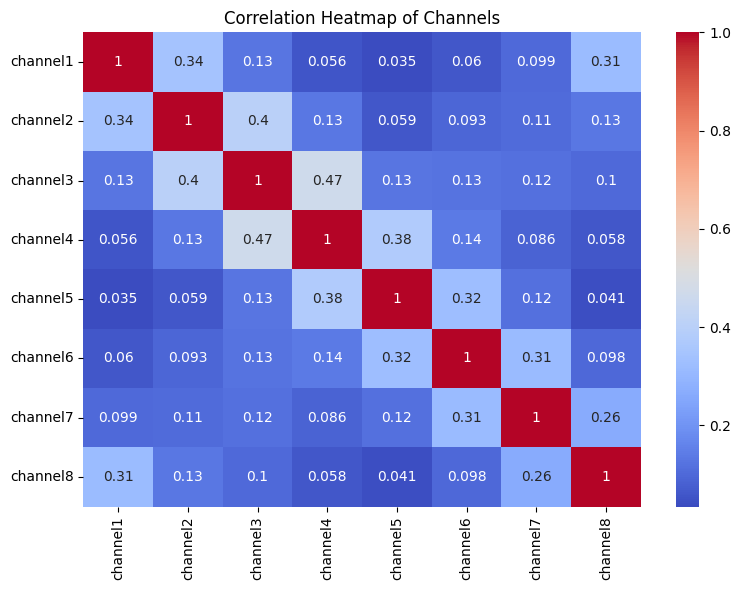

In [19]:
# correlation heatmap between channels 
correlation_matrix = df_without_unmarked[channel_cols].corr()
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', xticklabels=channel_cols, yticklabels=channel_cols)
plt.title(f'Correlation Heatmap of Channels')
plt.tight_layout()
plt.show()

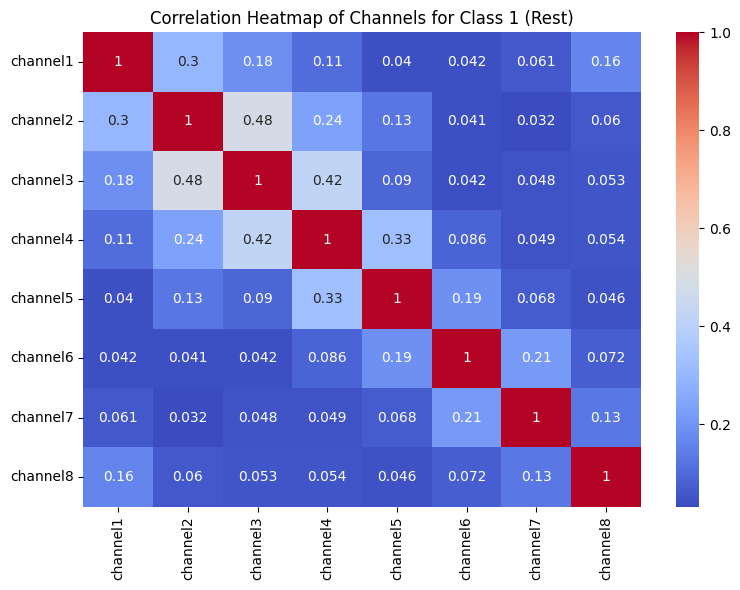

In [20]:
# correlation heatmap between channels for class 1 (Rest)
correlation_matrix_1 = df_without_unmarked[df_without_unmarked['class'] == 1][channel_cols].corr()
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix_1, annot=True, cmap='coolwarm', xticklabels=channel_cols, yticklabels=channel_cols)
plt.title(f'Correlation Heatmap of Channels for Class 1 (Rest)')
plt.tight_layout()
plt.show()

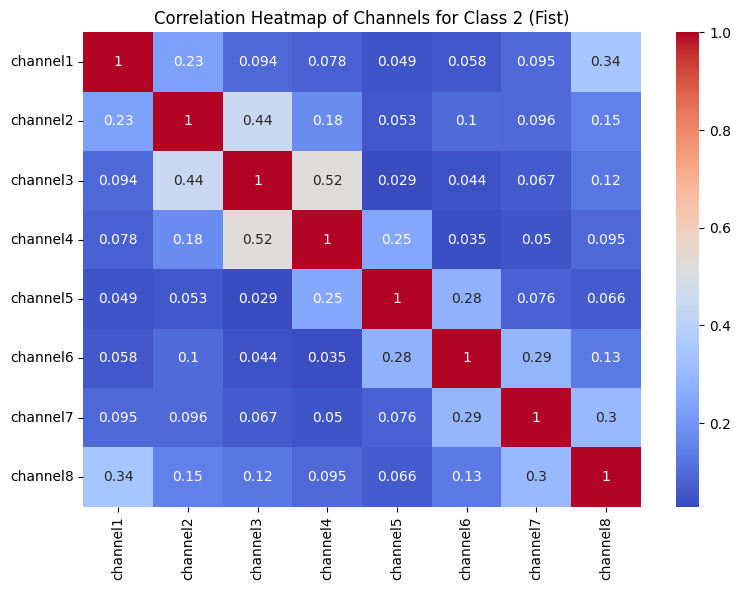

In [21]:
# correlation heatmap between channels for class 2 (Fist)
correlation_matrix_2 = df_without_unmarked[df_without_unmarked['class'] == 2][channel_cols].corr()
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix_2, annot=True, cmap='coolwarm', xticklabels=channel_cols, yticklabels=channel_cols)
plt.title(f'Correlation Heatmap of Channels for Class 2 (Fist)')
plt.tight_layout()
plt.show()

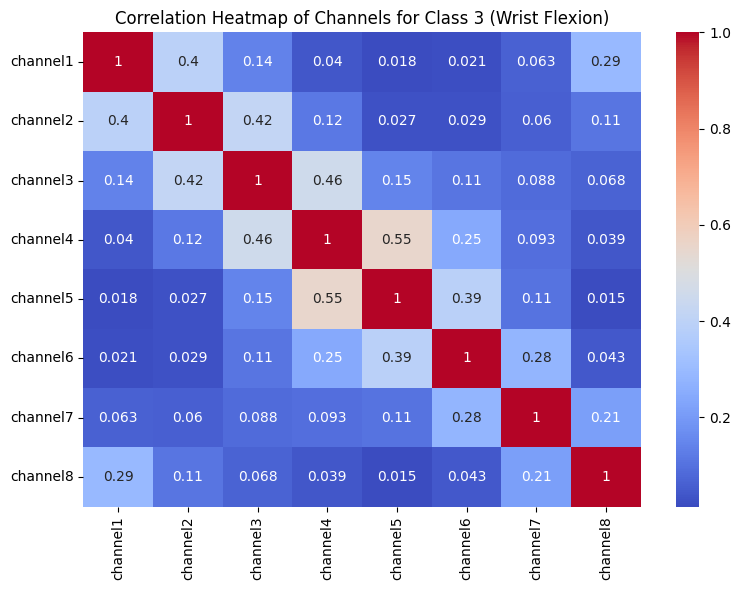

In [22]:
# correlation heatmap between channels for class 3 (Wrist Flexion)
correlation_matrix_3 = df_without_unmarked[df_without_unmarked['class'] == 3][channel_cols].corr()
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix_3, annot=True, cmap='coolwarm', xticklabels=channel_cols, yticklabels=channel_cols)
plt.title(f'Correlation Heatmap of Channels for Class 3 (Wrist Flexion)')
plt.tight_layout()
plt.show()

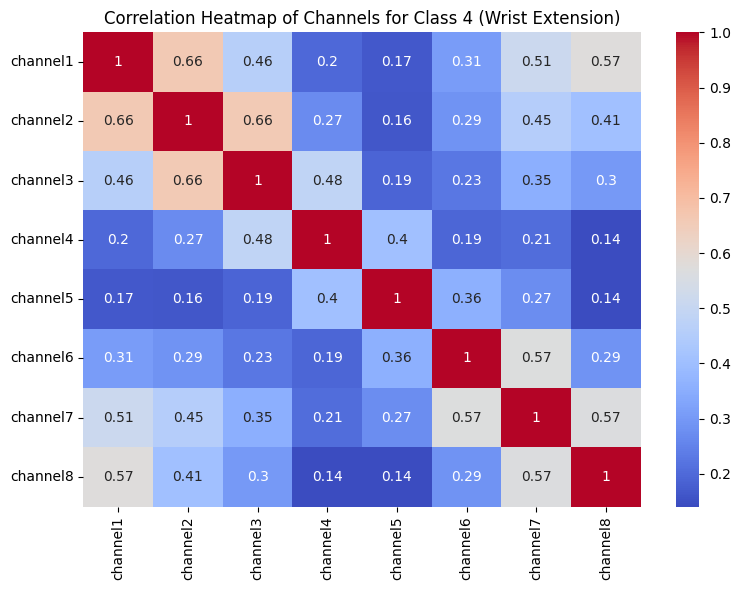

In [23]:
# correlation heatmap between channels for class 4 (Wrist Extension)
correlation_matrix_4 = df_without_unmarked[df_without_unmarked['class'] == 4][channel_cols].corr()
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix_4, annot=True, cmap='coolwarm', xticklabels=channel_cols, yticklabels=channel_cols)
plt.title(f'Correlation Heatmap of Channels for Class 4 (Wrist Extension)')
plt.tight_layout()
plt.show()

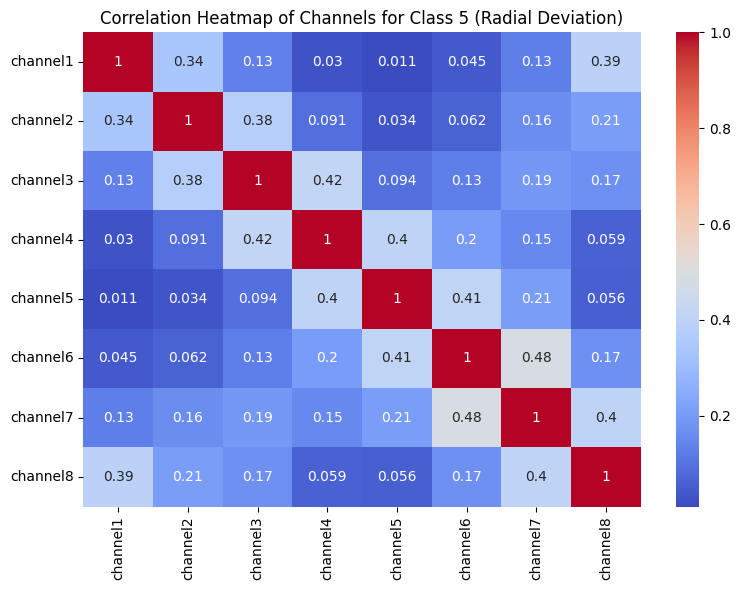

In [24]:
# correlation heatmap between channels for class 5 (Radial Deviation)
correlation_matrix_5 = df_without_unmarked[df_without_unmarked['class'] == 5][channel_cols].corr()
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix_5, annot=True, cmap='coolwarm', xticklabels=channel_cols, yticklabels=channel_cols)
plt.title(f'Correlation Heatmap of Channels for Class 5 (Radial Deviation)')
plt.tight_layout()
plt.show()

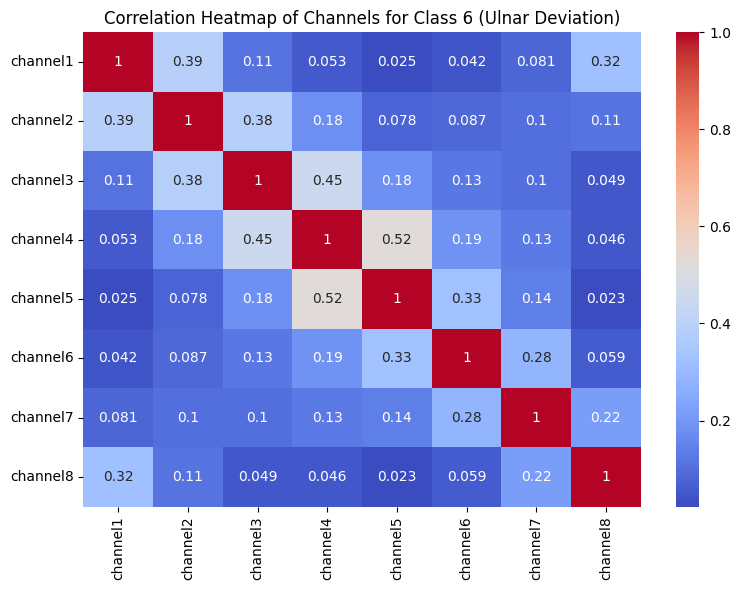

In [25]:
# correlation heatmap between channels for class 6 (Ulnar Deviation)
correlation_matrix_6 = df_without_unmarked[df_without_unmarked['class'] == 6][channel_cols].corr()
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix_6, annot=True, cmap='coolwarm', xticklabels=channel_cols, yticklabels=channel_cols)
plt.title(f'Correlation Heatmap of Channels for Class 6 (Ulnar Deviation)')
plt.tight_layout()
plt.show()

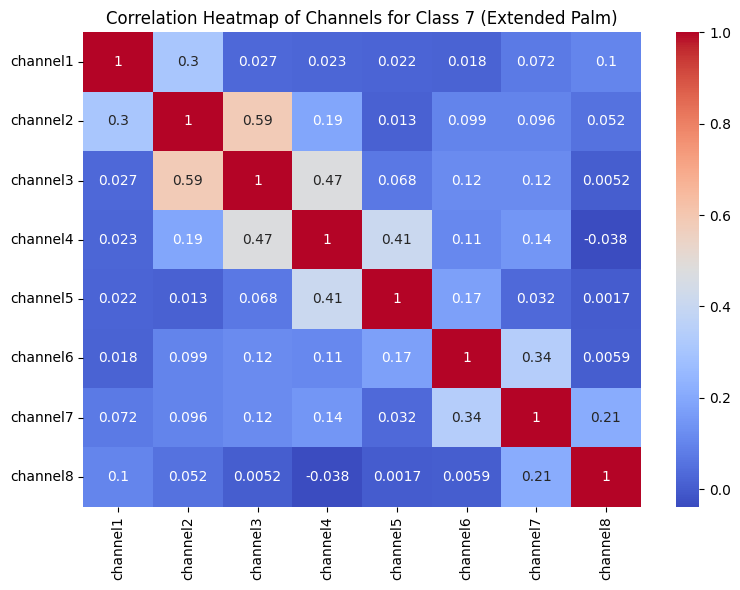

In [26]:
# correlation heatmap between channels for class 7 (Extended Palm)
correlation_matrix_7 = df_without_unmarked[df_without_unmarked['class'] == 7][channel_cols].corr()
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix_7, annot=True, cmap='coolwarm', xticklabels=channel_cols, yticklabels=channel_cols)
plt.title(f'Correlation Heatmap of Channels for Class 7 (Extended Palm)')
plt.tight_layout()
plt.show()

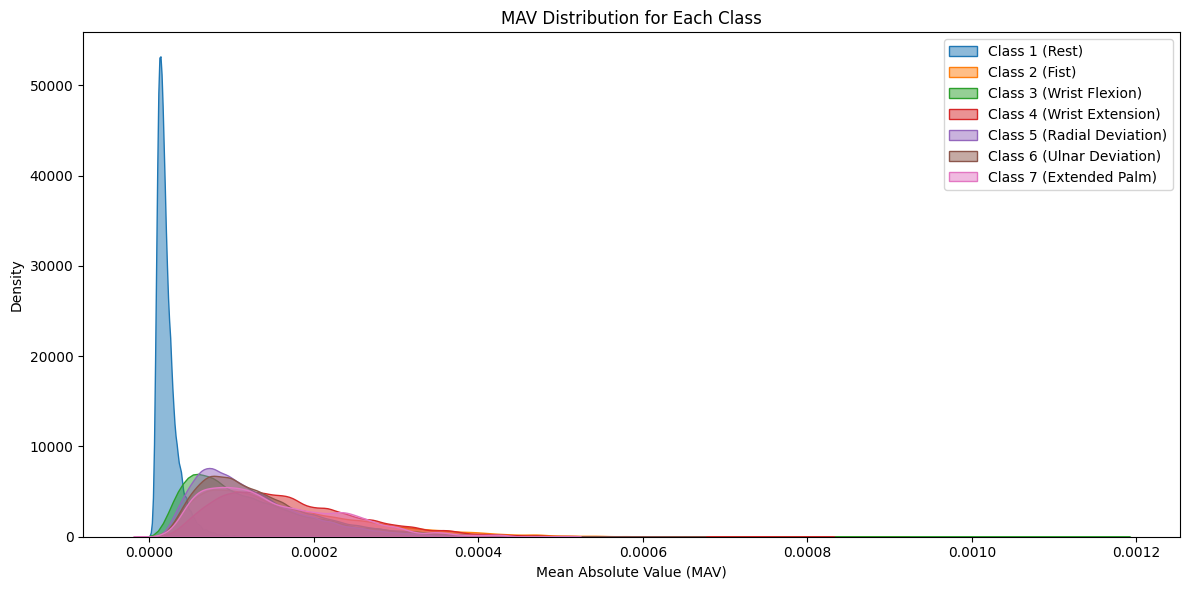

In [27]:
# MAV distribution for each class
plt.figure(figsize=(12, 6))
for i, (class_label, group) in enumerate(df_without_unmarked.groupby('class')):
    mav_values = group[channel_cols].abs().mean(axis=1)
    sns.kdeplot(mav_values, label=f'Class {class_label} ({gesture_names[class_label]})', fill=True, alpha=0.5)
plt.title('MAV Distribution for Each Class')
plt.xlabel('Mean Absolute Value (MAV)')
plt.legend()
plt.tight_layout()
plt.show()

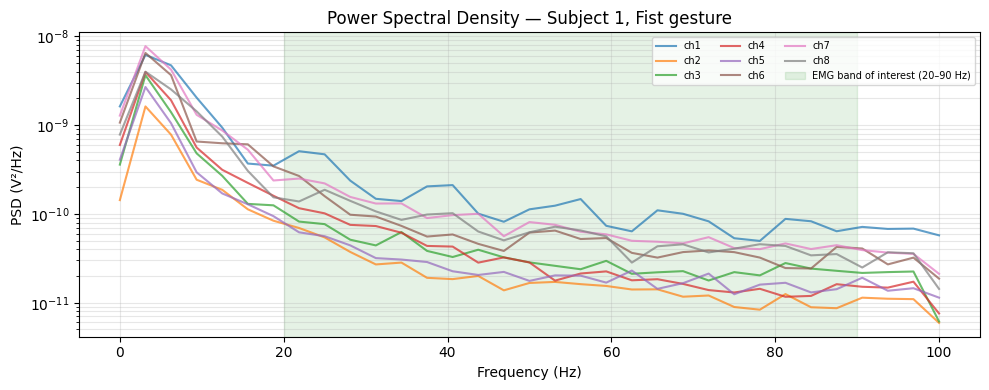

Note: EMG energy is concentrated between ~20 Hz and ~90 Hz at 200 Hz sampling rate.
Low-frequency content (<20 Hz) is motion artefact; above 90 Hz is mostly noise at this fs.


In [28]:
# ── Power Spectral Density (PSD) ──────────────────────────────────────────────
# Welch's method gives a smooth, averaged PSD — far more reliable than a single
# FFT on a short window.  The PSD tells us where the signal energy lives and
# helps us set the bandpass filter limits sensibly.

from scipy.signal import welch

fig, ax = plt.subplots(figsize=(10, 4))

for idx, ch in enumerate(channel_cols):
    signal = subject1_class2[ch].values
    freqs, psd = welch(signal, fs=200, nperseg=min(64, len(signal)))
    ax.semilogy(freqs, psd, label=f'ch{idx+1}', alpha=0.7)

ax.axvspan(20, 90, alpha=0.1, color='green', label='EMG band of interest (20–90 Hz)')
ax.set_xlabel('Frequency (Hz)')
ax.set_ylabel('PSD (V²/Hz)')
ax.set_title('Power Spectral Density — Subject 1, Fist gesture')
ax.legend(fontsize=7, ncol=3)
ax.grid(True, which='both', alpha=0.3)
plt.tight_layout()
plt.savefig('psd.png', dpi=120, bbox_inches='tight')
plt.show()

print('Note: EMG energy is concentrated between ~20 Hz and ~90 Hz at 200 Hz sampling rate.')
print('Low-frequency content (<20 Hz) is motion artefact; above 90 Hz is mostly noise at this fs.')

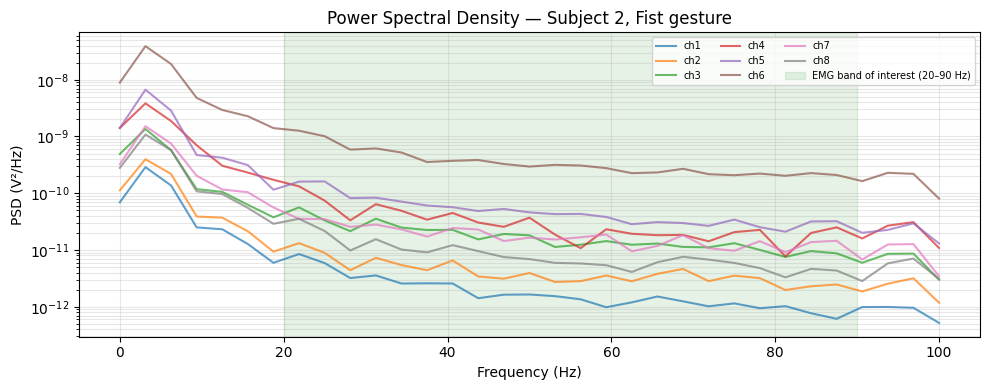

In [29]:
fig, ax = plt.subplots(figsize=(10, 4))

for idx, ch in enumerate(channel_cols):
    signal = subject2_class2[ch].values
    freqs, psd = welch(signal, fs=200, nperseg=min(64, len(signal)))
    ax.semilogy(freqs, psd, label=f'ch{idx+1}', alpha=0.7)

ax.axvspan(20, 90, alpha=0.1, color='green', label='EMG band of interest (20–90 Hz)')
ax.set_xlabel('Frequency (Hz)')
ax.set_ylabel('PSD (V²/Hz)')
ax.set_title('Power Spectral Density — Subject 2, Fist gesture')
ax.legend(fontsize=7, ncol=3)
ax.grid(True, which='both', alpha=0.3)
plt.tight_layout()
plt.savefig('psd2.png', dpi=120, bbox_inches='tight')
plt.show()

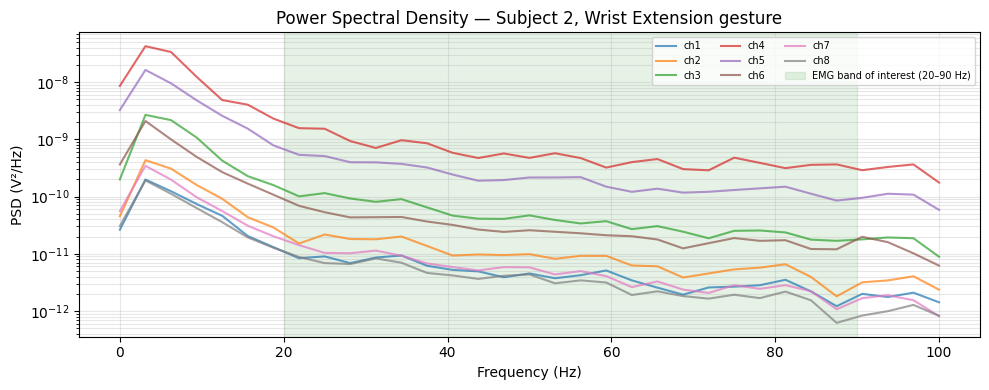

In [30]:
fig, ax = plt.subplots(figsize=(10, 4))
subject2_class4 = df[(df['label'] == subject_id_2) & (df['class'] == 4)].iloc[:600]
for idx, ch in enumerate(channel_cols):
    signal = subject2_class4[ch].values
    freqs, psd = welch(signal, fs=200, nperseg=min(64, len(signal)))
    ax.semilogy(freqs, psd, label=f'ch{idx+1}', alpha=0.7)

ax.axvspan(20, 90, alpha=0.1, color='green', label='EMG band of interest (20–90 Hz)')
ax.set_xlabel('Frequency (Hz)')
ax.set_ylabel('PSD (V²/Hz)')
ax.set_title('Power Spectral Density — Subject 2, Wrist Extension gesture')
ax.legend(fontsize=7, ncol=3)
ax.grid(True, which='both', alpha=0.3)
plt.tight_layout()
plt.savefig('psd3.png', dpi=120, bbox_inches='tight')
plt.show()

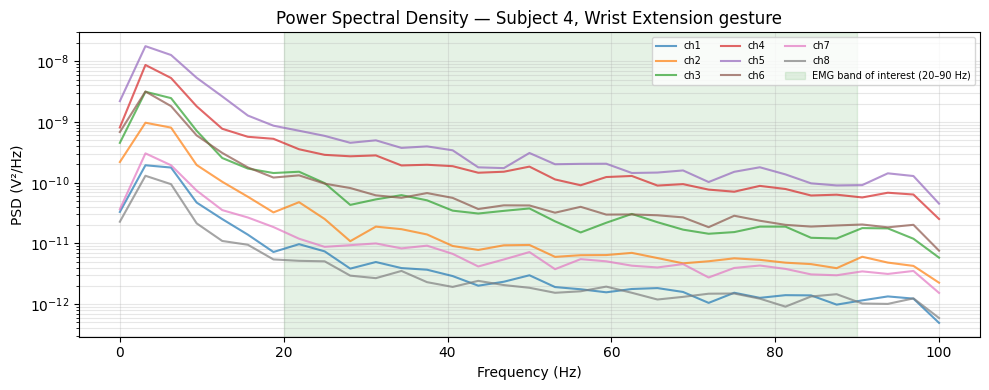

In [31]:
fig, ax = plt.subplots(figsize=(10, 4))
subject_id_4 = unique_subjects[3]
subject4_class4 = df[(df['label'] == subject_id_4) & (df['class'] == 4)].iloc[:600]
for idx, ch in enumerate(channel_cols):
    signal = subject4_class4[ch].values
    freqs, psd = welch(signal, fs=200, nperseg=min(64, len(signal)))
    ax.semilogy(freqs, psd, label=f'ch{idx+1}', alpha=0.7)

ax.axvspan(20, 90, alpha=0.1, color='green', label='EMG band of interest (20–90 Hz)')
ax.set_xlabel('Frequency (Hz)')
ax.set_ylabel('PSD (V²/Hz)')
ax.set_title('Power Spectral Density — Subject 4, Wrist Extension gesture')
ax.legend(fontsize=7, ncol=3)
ax.grid(True, which='both', alpha=0.3)
plt.tight_layout()
plt.savefig('psd4.png', dpi=120, bbox_inches='tight')
plt.show()

## 5. Filtering the Signal

Let the signal be concentrated in the frequency range 20 Hz - 90 Hz

In [32]:
print('Original shape:', df.shape)
print('After removing class 0:', df_without_unmarked.shape)
print(df_without_unmarked['class'].value_counts().sort_index())

Original shape: (4237907, 11)
After removing class 0: (1512750, 11)
class
1    250055
2    243193
3    249494
4    251570
5    251733
6    253009
7     13696
Name: count, dtype: int64


## 6. Simple Feature Extraction

Instead of using the raw EMG signal directly, we summarize each subject and gesture using simple features from each channel.

For each channel, we calculate:

- **MAV**: Mean Absolute Value, representing average muscle activation
- **RMS**: Root Mean Square, representing signal power
- **Variance**: representing signal spread

This gives 3 features × 8 channels = 24 features.

In [33]:
# For feature extraction, we will use a sliding window approach to compute features like Mean Absolute Value (MAV), Root Mean Square (RMS), and Variance (VAR) for each channel.
# We will use a window size of 200 samples (1 second at 200 Hz) with no overlap for simplicity.
window_size = 200

features = []

# for each subject, each gesture, and each window, compute features and store in a list of dicts
for subject in df_without_unmarked['label'].unique():
    subject_data = df_without_unmarked[df_without_unmarked['label'] == subject]

    # for each gesture, compute features in sliding windows
    for gesture in subject_data['class'].unique():
        gesture_data = subject_data[subject_data['class'] == gesture]

        # slide a window across the gesture data and compute features for each window
        for start in range(0, len(gesture_data) - window_size + 1, window_size):
            window = gesture_data.iloc[start:start + window_size]

            row = {
                'label': subject,
                'class': gesture
            }

            # compute features for each channel in the window
            for ch in channel_cols:
                signal = window[ch].values

                row[f'{ch}_MAV'] = np.mean(np.abs(signal))
                row[f'{ch}_RMS'] = np.sqrt(np.mean(signal**2))
                row[f'{ch}_VAR'] = np.var(signal)

            features.append(row)

features_df = pd.DataFrame(features)

features_df.head()

,label,class,channel1_MAV,channel1_RMS,channel1_VAR,channel2_MAV,channel2_RMS,channel2_VAR,channel3_MAV,channel3_RMS,...,channel5_VAR,channel6_MAV,channel6_RMS,channel6_VAR,channel7_MAV,channel7_RMS,channel7_VAR,channel8_MAV,channel8_RMS,channel8_VAR
0,1,1,0.000016,0.000019,1.290000e-10,0.000022,0.000028,4.851600e-10,0.000023,0.000029,...,1.469375e-10,0.000009,0.000012,9.376000e-11,0.000011,0.000013,1.111600e-10,0.000011,0.000013,1.047500e-10
1,1,1,0.000008,0.000011,1.009375e-10,0.000016,0.000023,5.033775e-10,0.000030,0.000035,...,1.782400e-10,0.000014,0.000016,1.085900e-10,0.000012,0.000015,8.043750e-11,0.000011,0.000014,6.619000e-11
2,1,1,0.000010,0.000014,1.123100e-10,0.000017,0.000025,5.219600e-10,0.000024,0.000029,...,5.375000e-11,0.000008,0.000012,6.876000e-11,0.000011,0.000013,8.243750e-11,0.000012,0.000014,9.393750e-11
3,1,1,0.000014,0.000018,2.090400e-10,0.000019,0.000022,2.699975e-10,0.000018,0.000024,...,1.193100e-10,0.000007,0.000011,8.467750e-11,0.000011,0.000014,1.140000e-10,0.000012,0.000014,7.651000e-11
4,1,1,0.000013,0.000016,1.363600e-10,0.000020,0.000024,4.684975e-10,0.000019,0.000025,...,1.992975e-10,0.000013,0.000017,2.080000e-10,0.000008,0.000012,8.071000e-11,0.000011,0.000015,1.224375e-10


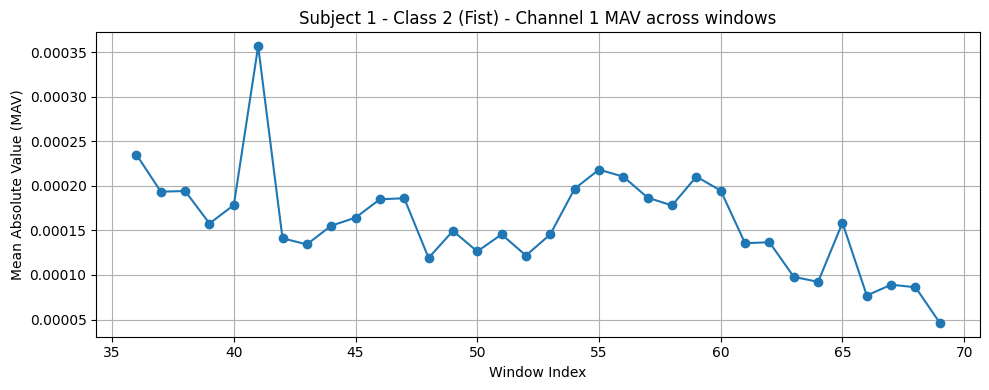

In [34]:
# plot subject 1, class 2 (Fist) MAV for channel 1 across windows
subject_id = unique_subjects[0]  # Subject 1
gesture_class = 2  # Fist
subject1_class2_features = features_df[(features_df['label'] == subject_id) & (features_df['class'] == gesture_class)]
plt.figure(figsize=(10, 4))
plt.plot(subject1_class2_features[f'channel1_MAV'], marker='o')
plt.title(f'Subject {subject_id} - Class {gesture_class} ({gesture_names[gesture_class]}) - Channel 1 MAV across windows')
plt.xlabel('Window Index')
plt.ylabel('Mean Absolute Value (MAV)')
plt.grid(True)
plt.tight_layout()
plt.show()

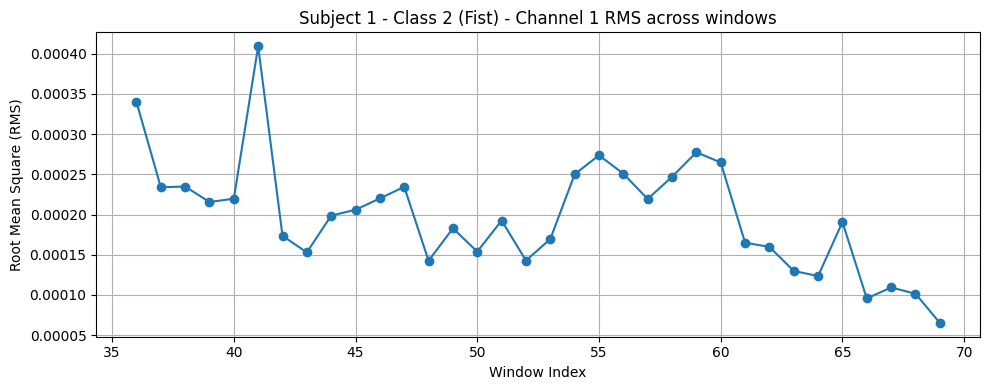

In [35]:
# plot subject 1, class 2 (Fist) RMS for channel 1 across windows
subject_id = unique_subjects[0]  # Subject 1
gesture_class = 2  # Fist
subject1_class2_features = features_df[(features_df['label'] == subject_id) & (features_df['class'] == gesture_class)]
plt.figure(figsize=(10, 4))
plt.plot(subject1_class2_features[f'channel1_RMS'], marker='o')
plt.title(f'Subject {subject_id} - Class {gesture_class} ({gesture_names[gesture_class]}) - Channel 1 RMS across windows')
plt.xlabel('Window Index')
plt.ylabel('Root Mean Square (RMS)')
plt.grid(True)
plt.tight_layout()
plt.show()

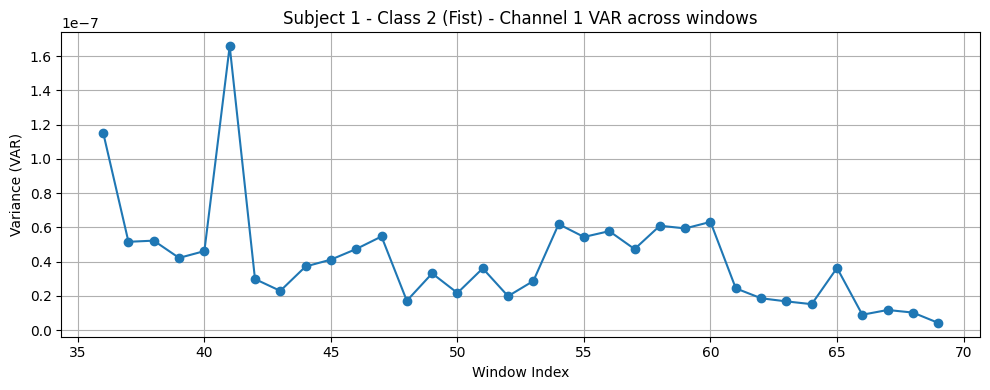

In [36]:
# plot subject 1, class 2 (Fist) VAR for channel 1 across windows
subject_id = unique_subjects[0]  # Subject 1
gesture_class = 2  # Fist
subject1_class2_features = features_df[(features_df['label'] == subject_id) & (features_df['class'] == gesture_class)]
plt.figure(figsize=(10, 4))
plt.plot(subject1_class2_features[f'channel1_VAR'], marker='o')
plt.title(f'Subject {subject_id} - Class {gesture_class} ({gesture_names[gesture_class]}) - Channel 1 VAR across windows')
plt.xlabel('Window Index')
plt.ylabel('Variance (VAR)')
plt.grid(True)
plt.tight_layout()
plt.show()

In [37]:
X = features_df.drop(columns=['class', 'label']) # features only
y = features_df['class'] # labels only (gesture class)
subjects = features_df['label'] # subject IDs (for potential subject-wise splitting later)

In [38]:
# For a simple subject-wise split, we can take the first 30 subjects for training and the remaining 6 for testing (since there are 36 subjects total).

train_subjects = subjects.unique()[:30]
test_subjects = subjects.unique()[30:]

X_train = X[subjects.isin(train_subjects)]
y_train = y[subjects.isin(train_subjects)]

X_test = X[subjects.isin(test_subjects)]
y_test = y[subjects.isin(test_subjects)]

In [39]:
# Standardize features (zero mean, unit variance) - important for many ML algorithms
# We fit the scaler on the training data and then transform both training and test data to avoid data leakage.
# Note: We could also consider more advanced scaling techniques or feature selection later, but StandardScaler is a good starting point.

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [40]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

model_rf = RandomForestClassifier()

model_rf.fit(X_train_scaled, y_train)

y_pred_rf = model_rf.predict(X_test_scaled)

print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

Accuracy: 0.8911960132890365
              precision    recall  f1-score   support

           1       1.00      1.00      1.00       203
           2       0.89      0.94      0.92       198
           3       0.75      0.89      0.81       199
           4       0.87      0.92      0.89       203
           5       0.98      0.88      0.93       204
           6       0.89      0.71      0.79       197

    accuracy                           0.89      1204
   macro avg       0.90      0.89      0.89      1204
weighted avg       0.90      0.89      0.89      1204



Confusion Matrix:
 [[203   0   0   0   0   0]
 [  0 187   6   1   1   3]
 [  0  17 177   2   1   2]
 [  0   2   0 187   1  13]
 [  0   0   2  23 179   0]
 [  0   3  52   2   0 140]]
Random Forest Classifier - TP: 0.89, TN: 0.00, FP: 0.11, FN: 0.11


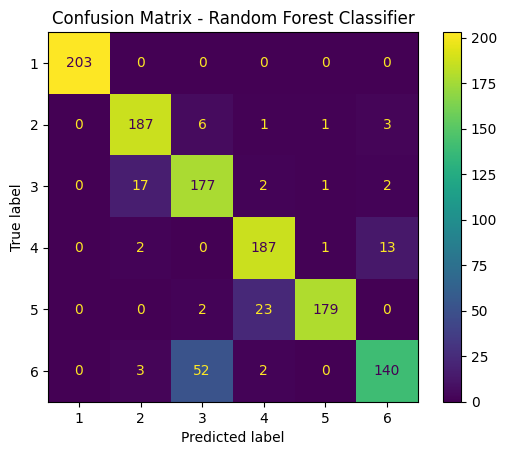

In [41]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm_rf = confusion_matrix(y_test, y_pred_rf)
print("Confusion Matrix:\n", cm_rf)

fp_rf = 0
fn_rf = 0
tp_rf = 0
tn_rf = 0
total = cm_rf.sum()

# Calculate false positives, false negatives, true positives, and true negatives for the Random Forest classifier
for i in range(cm_rf.shape[0]):
    for j in range(cm_rf.shape[1]):
        if i == j:
            tp_rf += cm_rf[i, j]
        else:
            fp_rf += cm_rf[i, j]
            fn_rf += cm_rf[j, i]

print(f"Random Forest Classifier - TP: {tp_rf/total:.2f}, TN: {tn_rf/total:.2f}, FP: {fp_rf/total:.2f}, FN: {fn_rf/total:.2f}")

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_rf)
plt.title("Confusion Matrix - Random Forest Classifier")
plt.show()

In [42]:
# Logistic Regression
model_lr = LogisticRegression(max_iter=1000)
model_lr.fit(X_train_scaled, y_train)
y_pred_lr = model_lr.predict(X_test_scaled)
print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr))

Logistic Regression Accuracy: 0.8679401993355482
              precision    recall  f1-score   support

           1       1.00      1.00      1.00       203
           2       0.90      0.89      0.90       198
           3       0.70      0.85      0.77       199
           4       0.90      0.85      0.87       203
           5       0.93      0.90      0.92       204
           6       0.80      0.71      0.75       197
           7       0.00      0.00      0.00         0

    accuracy                           0.87      1204
   macro avg       0.75      0.74      0.74      1204
weighted avg       0.87      0.87      0.87      1204



c:\Users\mcheh\OneDrive\Desktop\BioEngineering\EMG_project\venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\mcheh\OneDrive\Desktop\BioEngineering\EMG_project\venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\mcheh\OneDrive\Desktop\BioEngineering\EMG_project\venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(

## 7. Feature Visualization

Now we can visualize whether the extracted features differ across gesture classes. This is usually easier to interpret than raw EMG signals.

<Figure size 1000x400 with 0 Axes>

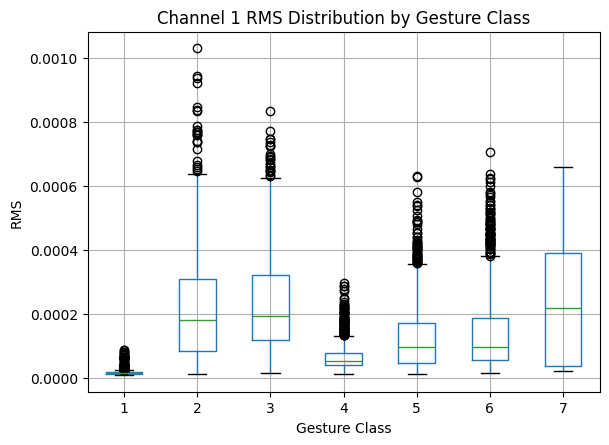

In [43]:
plt.figure(figsize=(10, 4))
features_df.boxplot(column='channel1_RMS', by='class')
plt.title('Channel 1 RMS Distribution by Gesture Class')
plt.suptitle('')
plt.xlabel('Gesture Class')
plt.ylabel('RMS')
plt.show()

## 8. PCA Visualization

PCA reduces the feature table to two dimensions so we can visualize whether the gesture classes form separate clusters.

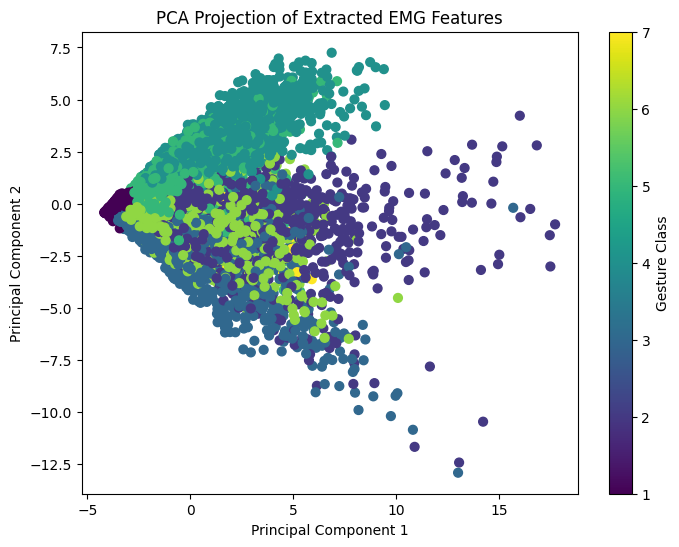

In [44]:
X = features_df.drop(columns=['label', 'class'])
y = features_df['class']

X_scaled = StandardScaler().fit_transform(X)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(8, 6))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y, s=40)
plt.title('PCA Projection of Extracted EMG Features')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.colorbar(scatter, label='Gesture Class')
plt.show()

## 9. Split by Subject

The subject label should not be used as an input feature. Instead, we use it to split the data.

This means the model trains on some subjects and tests on different subjects. This is a stronger test because it checks whether the model can generalize to new people.

In [45]:
subjects = sorted(features_df['label'].unique())

split_point = int(0.8 * len(subjects))
train_subjects = subjects[:split_point]
test_subjects = subjects[split_point:]

train_df = features_df[features_df['label'].isin(train_subjects)]
test_df = features_df[features_df['label'].isin(test_subjects)]

X_train = train_df.drop(columns=['label', 'class'])
y_train = train_df['class']

X_test = test_df.drop(columns=['label', 'class'])
y_test = test_df['class']

print('Training subjects:', train_subjects)
print('Testing subjects:', test_subjects)
print('X_train shape:', X_train.shape)
print('X_test shape:', X_test.shape)

Training subjects: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20), np.int64(21), np.int64(22), np.int64(23), np.int64(24), np.int64(25), np.int64(26), np.int64(27), np.int64(28)]
Testing subjects: [np.int64(29), np.int64(30), np.int64(31), np.int64(32), np.int64(33), np.int64(34), np.int64(35), np.int64(36)]
X_train shape: (5800, 24)
X_test shape: (1660, 24)


## 10. Train Two Simple Models

We train two beginner-friendly classification models:

- Logistic Regression
- Support Vector Machine (SVM)

The scaler is included because many ML models work better when features are on a similar scale.

In [46]:
models = {
    'Logistic Regression': Pipeline([
        ('scaler', StandardScaler()),
        ('model', LogisticRegression(max_iter=1000))
    ]),
    'SVM': Pipeline([
        ('scaler', StandardScaler()),
        ('model', SVC())
    ])
}

results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    results[name] = {'model': model, 'y_pred': y_pred, 'accuracy': acc}
    print(f'{name} Accuracy: {acc:.3f}')

Logistic Regression Accuracy: 0.777
SVM Accuracy: 0.772


## 11. Evaluate the Model

Accuracy gives a quick overall result, while the confusion matrix shows which gestures were classified correctly and which gestures were confused with each other.

Best model: Logistic Regression
Classification Report:
              precision    recall  f1-score   support

           1       0.93      0.96      0.94       274
           2       0.92      0.79      0.85       266
           3       0.67      0.73      0.70       273
           4       0.74      0.81      0.77       273
           5       0.78      0.80      0.79       273
           6       0.66      0.67      0.66       269
           7       0.00      0.00      0.00        32

    accuracy                           0.78      1660
   macro avg       0.67      0.68      0.67      1660
weighted avg       0.77      0.78      0.77      1660



c:\Users\mcheh\OneDrive\Desktop\BioEngineering\EMG_project\venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\mcheh\OneDrive\Desktop\BioEngineering\EMG_project\venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\mcheh\OneDrive\Desktop\BioEngineering\EMG_project\venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control thi

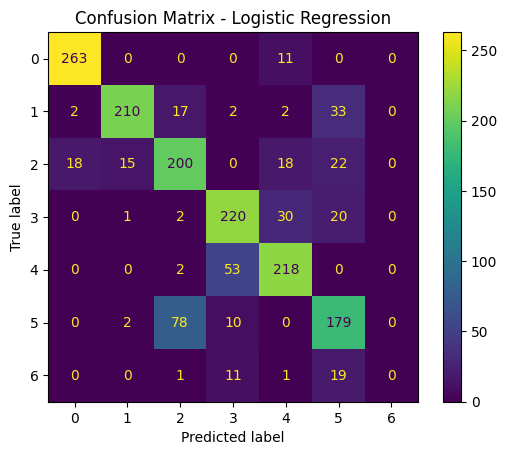

In [47]:
best_model_name = max(results, key=lambda name: results[name]['accuracy'])
best_pred = results[best_model_name]['y_pred']

print('Best model:', best_model_name)
print('Classification Report:')
print(classification_report(y_test, best_pred))

cm = confusion_matrix(y_test, best_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title(f'Confusion Matrix - {best_model_name}')
plt.show()

## 12. Summary

This simplified pipeline used the EMG channels to classify hand gestures. The workflow was:

1. Load and inspect the dataset  
2. Remove unmarked class 0 samples  
3. Extract simple features from each EMG channel  
4. Split the data by subject  
5. Train classification models  
6. Evaluate using accuracy and a confusion matrix

This version is intentionally simple. More advanced versions can add filtering, sliding windows, frequency-domain features, and cross-validation.